In [2]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import math as math

from scripts.readTdi import readTdi, getTdiPath
from scripts.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.whitenPsdNoise import n_whitened_time_noises_from_psd, whitened_time_noise_from_psd, n_whiten_noise_psds
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_bias, plot_residual_histogram, plot_median_histogram, draw_segments
from scripts.mle import mle_df
from scripts.medianFuncs import median_exp_pdf, confidence_interval, median_pdf, harmonic_factor

from scipy.special import digamma        # ψ(x) = H_{x-1} - γ

In [3]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

# plot(data, t, fs, f_orig, orig_psd,  nperseg, title="TDI-X", bigtitle="PSD graphs")

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

In [3]:
math.log(2)


0.6931471805599453

mu: 2.2846534803828183e-39
histogram: [9.36290873e-40 4.43300989e-39 1.33838845e-39 ... 3.28683012e-39
 4.06961188e-39 1.25789373e-39]


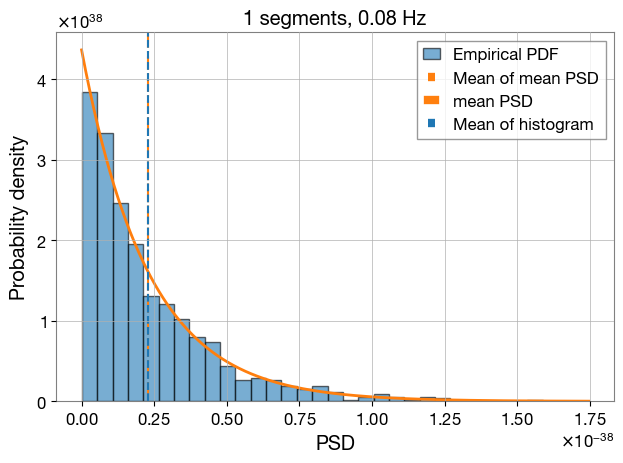

mu: 1.4183174500644429e-39
histogram: [8.44671894e-40 6.38646270e-40 8.28152742e-40 ... 2.46060596e-39
 5.63346028e-40 8.50797431e-40]


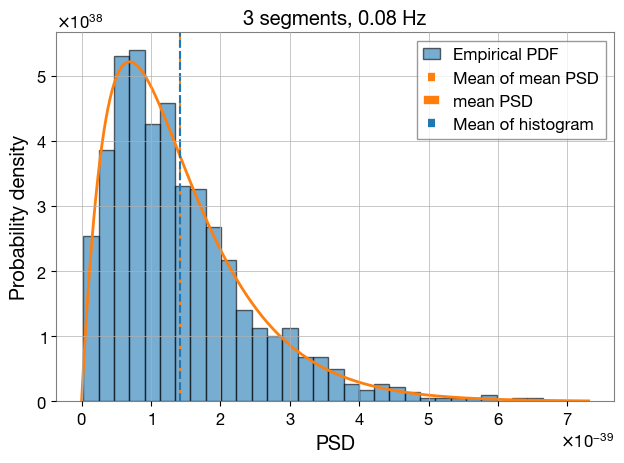

mu: 1.2790163742950859e-39
histogram: [8.25628342e-40 2.05969377e-39 9.60284673e-40 ... 9.67785148e-40
 1.94896038e-39 3.54598222e-40]


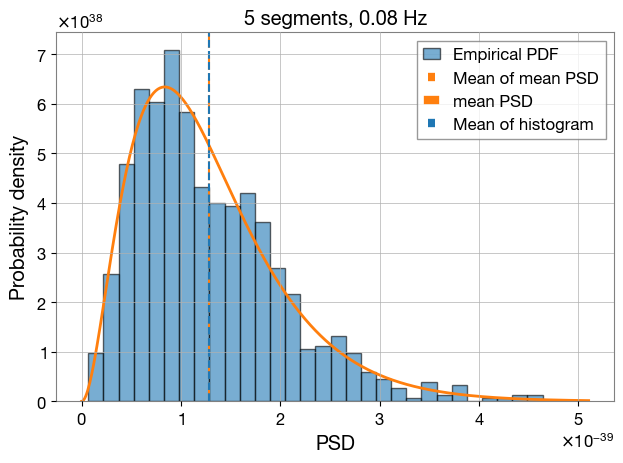

In [7]:
noverlap = 0
fraction = 0.8

nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30)


nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30)



nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30)

histogram: [3.57470472e-40 6.72295767e-39 2.10737989e-39 ... 1.86346869e-39
 1.22239663e-39 5.64630178e-40]


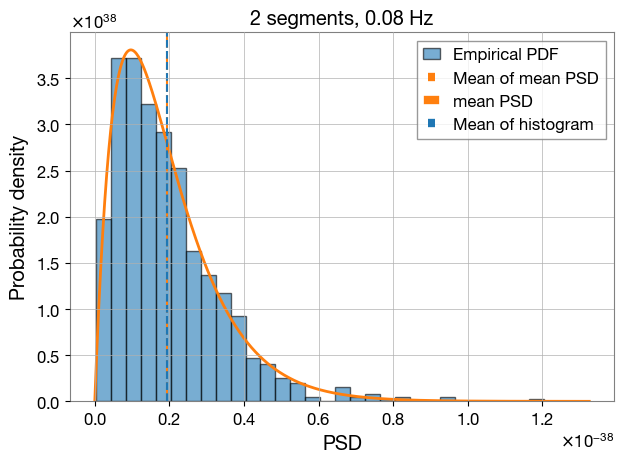

In [7]:
noverlap = 0
fraction = 0.8

nperseg_noise = 10000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

method = 'average'            # 'lower', 'upper', or 'average'

N    = nseg[0]
harm = harmonic_factor(N, method)

hist_mean = psd_noise_vals.mean()
lam  = hist_mean / harm       # scale estimate

plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30,
                      median_method=method)


mu: 1.646858592110427e-39
histogram: [2.87746465e-39 3.32035335e-39 2.68692250e-40 ... 3.62193357e-39
 1.58908970e-39 8.77062033e-40]


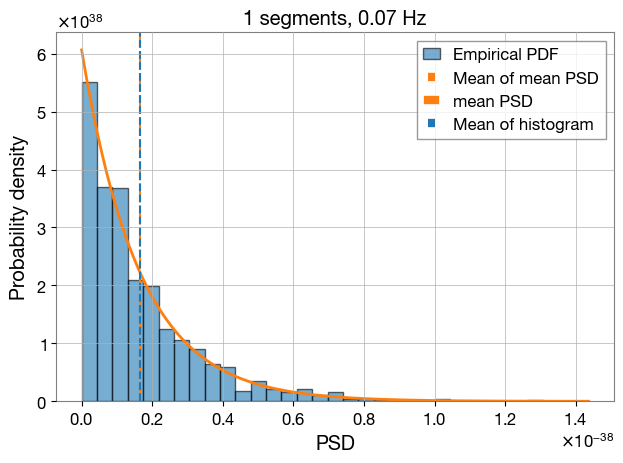

mu: 1.3741326446163082e-39
histogram: [1.79665109e-39 1.03698604e-39 1.37557470e-39 ... 1.57607939e-39
 9.29709305e-40 2.27433534e-39]


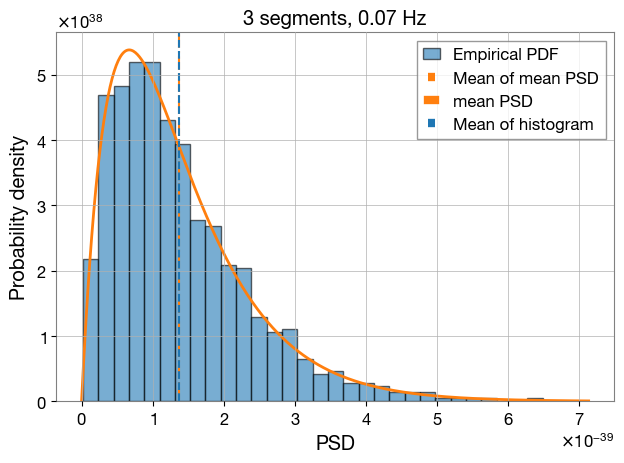

mu: 1.3640739194167447e-39
histogram: [1.22651738e-39 2.20589227e-39 8.27390130e-40 ... 2.15896404e-39
 3.07172521e-40 1.30995148e-39]


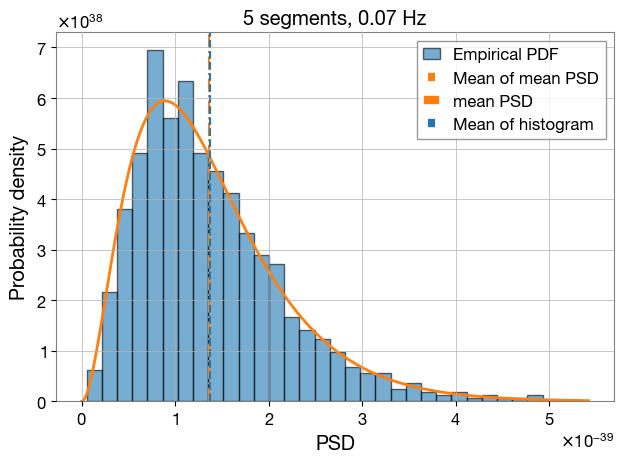

1.7924138271800836e-39


In [3]:
noverlap = 0
fraction = 0.7

nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30)


nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30)



nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

N   = nseg[0]                 
n   = (N - 1)//2
harm = digamma(N + 1) - digamma(n + 1) #  harmonic difference  H_{2n+1} - H_n   # same as sum(1/np.arange(n+1, N+1))

hist_mean = np.mean(psd_noise_vals)      # ⟨median⟩ from your 1000 realisations
lam = hist_mean / harm                  #  << correct scale parameter >>
plot_median_histogram(psd_noise_vals,
                      N,
                      [lam],            # not hist_mean, but λ!
                      labels=['mean PSD'],
                      title=f'{N} segments, {chosen_f_orig} Hz',
                      n_bins=30)
print(orig_psd_val)

PDF mean: 7.000024880669322e+37
PDF mean: 6.971966373440228e+37


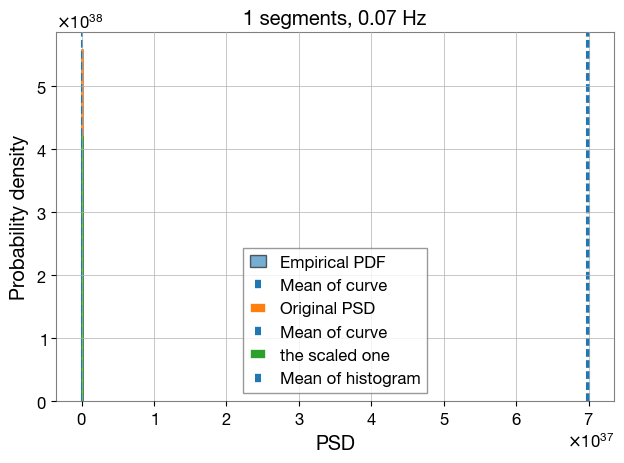

PDF mean: 1.397105142673271e+38
PDF mean: 1.3954292443190848e+38


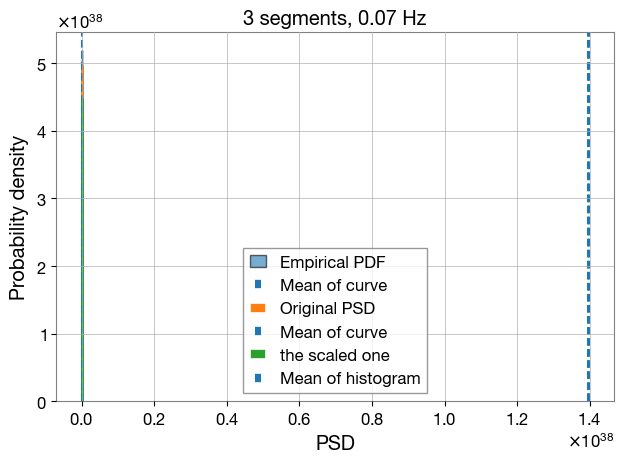

PDF mean: 1.8384523559202075e+38
PDF mean: 1.8360285819393505e+38


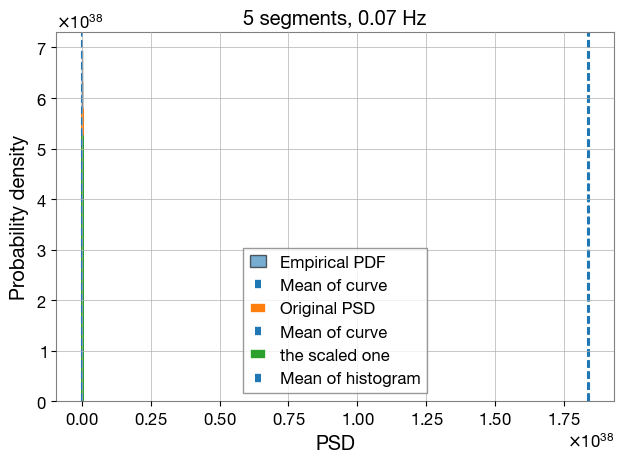

In [5]:
noverlap = 0
fraction = 0.7
nperseg_noise = 20000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
hist_mean = np.mean(psd_noise_vals)
plot_median_histogram(psd_noise_vals,
                      nseg[0],              # N  – must be odd
                      [orig_psd_val, hist_mean / 0.693],      # scale parameter of Exp
                      labels=["Original PSD", "the scaled one"],
                      title=f"{nseg[0]} segments, {chosen_f_orig} Hz",
                      n_bins=30)

nperseg_noise = 6000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
hist_mean = np.mean(psd_noise_vals)
plot_median_histogram(psd_noise_vals,
                      nseg[0],              # N  – must be odd
                      [orig_psd_val, hist_mean / 0.693],      # scale parameter of Exp
                      labels=["Original PSD", "the scaled one"],
                      title=f"{nseg[0]} segments, {chosen_f_orig} Hz",
                      n_bins=30)

nperseg_noise = 4000
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap, method='median')
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
hist_mean = np.mean(psd_noise_vals)
plot_median_histogram(psd_noise_vals,
                      nseg[0],              # N  – must be odd
                      [orig_psd_val, hist_mean / 0.693],      # scale parameter of Exp
                      labels=["Original PSD", "the scaled one"],
                      title=f"{nseg[0]} segments, {chosen_f_orig} Hz",
                      n_bins=30)

[10 10 10 ... 10 10 10]


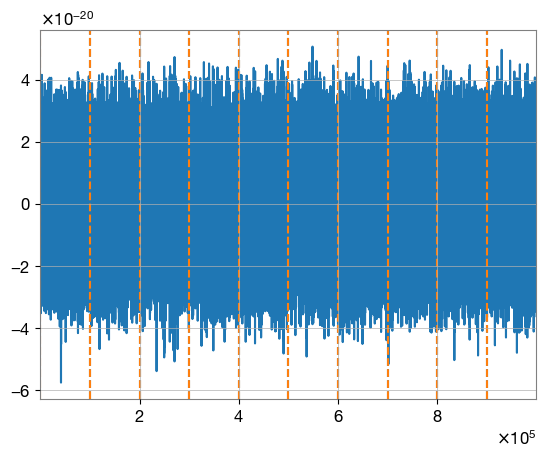

UnboundLocalError: cannot access local variable 'ax0' where it is not associated with a value

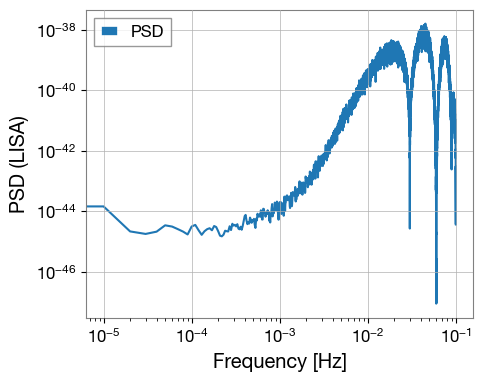

In [6]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, P_stack, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg,
    noverlap=0
) 
print(nseg)
# Plot the original psd for no reason 
draw_segments(t, data, nperseg, 0)
plot(data=data, t=t, fs=fs, f=f_orig, psd=[orig_psd], labels=["PSD"], nper=nperseg, title="TDI-X", show_time_series=False)
plot(data=data, t=t, fs=fs, f=f_orig, psd=[P_stack[0]], labels=["PSD of 1st segment"],  nper=nperseg, title="TDI-X", show_time_series=False)
plot(data=data, t=t, fs=fs, f=f_orig, psd=[P_stack[1]], labels=["PSD of 2nd segment"],  nper=nperseg, title="TDI-X", show_time_series=False)
plot(data=data, t=t, fs=fs, f=f_orig, psd=[P_stack[9]], labels=["PSD of 10th segment"],  nper=nperseg, title="TDI-X", show_time_series=False)


In [ ]:
print(t.size)
print(data.size)

200000
200000


In [ ]:
f_orig.size

10001

10


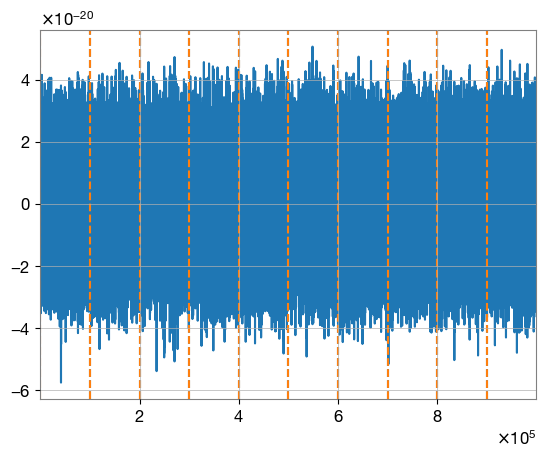

(<Figure size 500x400 with 1 Axes>,
 [<Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>])

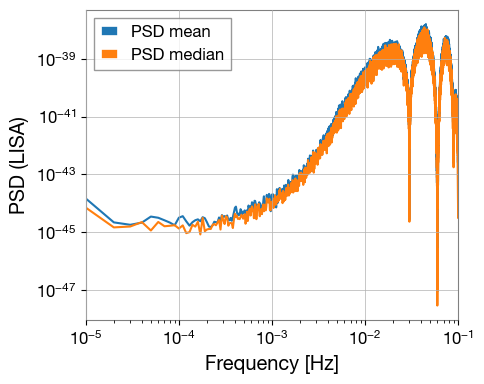

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, P_stack, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg,
    noverlap=0
) 
f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
print(nseg)
# Plot the original psd for no reason 
draw_segments(t, data, nperseg, 0)
plot(data=data, t=t, fs=fs, f=f_orig, psd=[orig_psd, orig_psd_median], labels=["PSD mean", "PSD median"], nper=nperseg, title="TDI-X", show_time_series=False)

Text(0, 0.5, 'Amplitude')

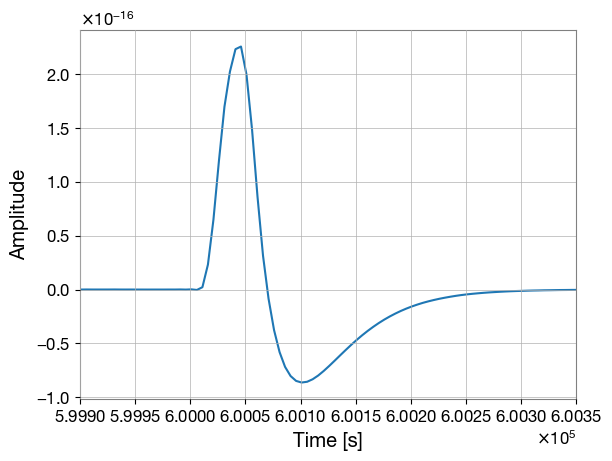

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
# plot(
#     data=data,
#     t=t, 
#     fs=fs, 
#     f=f_orig, 
#     nper=nperseg, 
#     psd= [orig_psd, orig_psd_mean],
#     labels= ["no glitch", "glitch"],
#     title="TDI-X", 
#     bigtitle="PSD graphs"
# )

import matplotlib.pyplot as plt
plt.plot(t, data)

plt.xlim(600000-100, 600000+350)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

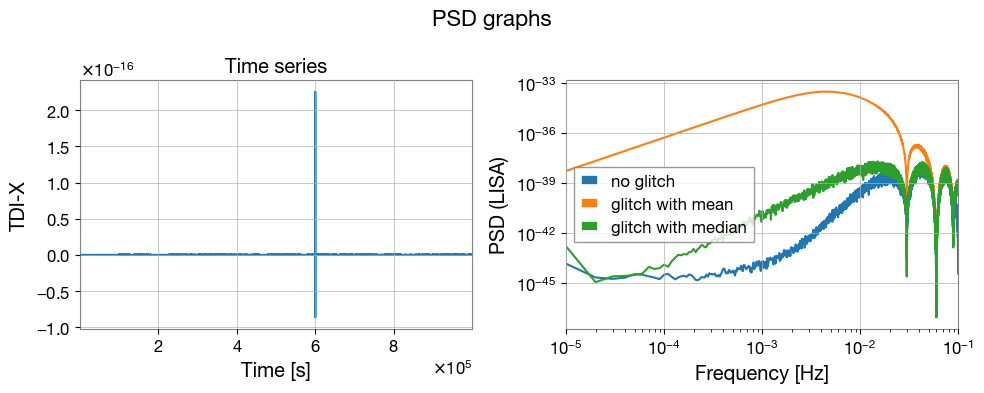

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

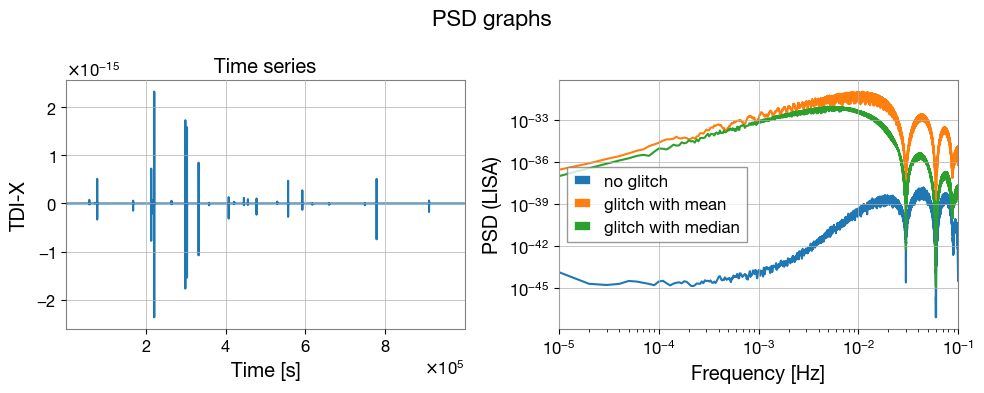

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('large_glitch_pos_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)


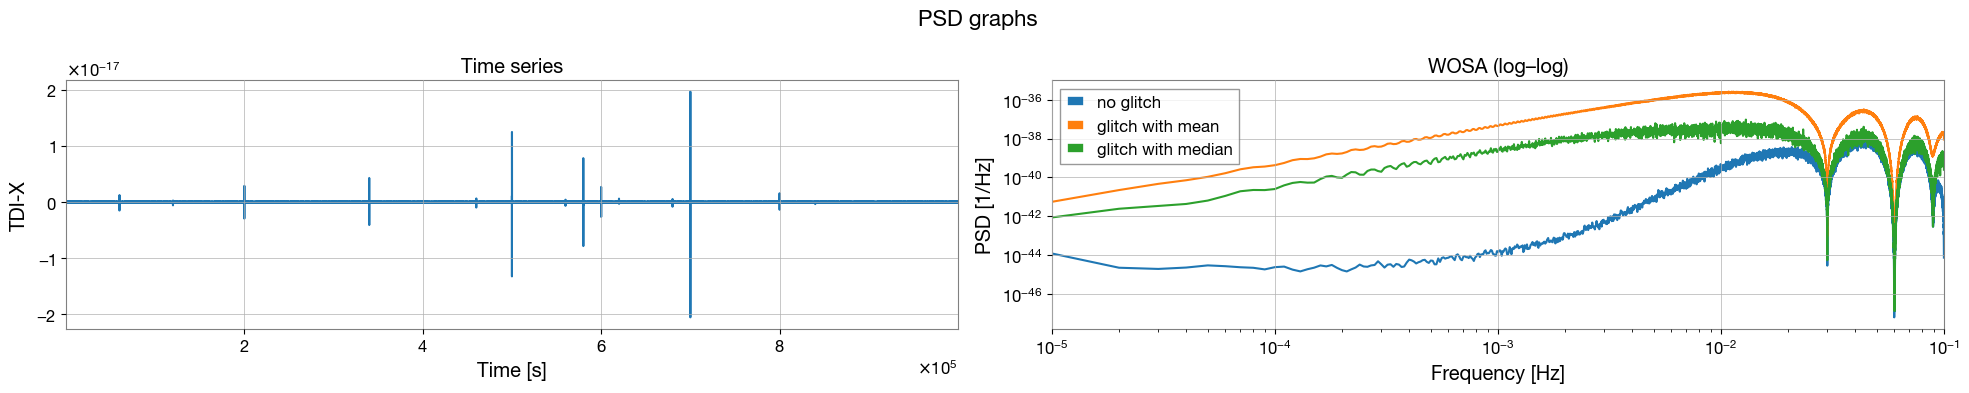

In [ ]:

# 1) Read the TDI time series
tdi_path = getTdiPath('medium_glitch_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig, orig_psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
# Plot the original psd for no reason 
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_orig, 
    nper=nperseg, 
    psd= [orig_psd, orig_psd_mean, orig_psd_median],
    labels= ["no glitch", "glitch with mean", "glitch with median"],
    title="TDI-X", 
    bigtitle="PSD graphs"
)

